# Brasil Real Estate Data

## Resumo

O conjunto de dados analisado reúne informações abrangentes sobre o mercado imobiliário no Brasil, contemplando propriedades disponíveis para venda e locação. Ele inclui características como tipo de imóvel, localização, tamanho e preços, permitindo uma visão geral das ofertas no mercado.

Além disso, o dataset incorpora informações sobre preços de venda e aluguel, possibilitando a análise de variações de valores entre diferentes regiões e tipos de imóveis.

Outro aspecto relevante é a presença de dados geográficos, como coordenadas, permitindo análises espaciais e identificação de áreas mais valorizadas.

Em conjunto, esses dados permitem uma análise exploratória completa, auxiliando na identificação de padrões, tendências e oportunidades no setor imobiliário brasileiro.

## Introdução e Contextualização

Brasil real estate dataset contém informações que incluem o tipo da propriedade, localização, tamanho e preço. Este dataset pode ser usado para análise de mercado, estimativa de preço da propriedade e idenficar tendencias no mercado imobiliário. A variável alvo é 'price_brl' e as principais variáveis preditoras (features), são: 'property_type', 'state', 'region', 'lat', 'lon' e 'area_m2'.

## Objetivos do Projeto

O objetivo é realizar uma análise comparativa entre três abordagens de regressão para prever um
valor contínuo, identificando qual modelo possui o melhor poder de generalização e explicando o
porquê da superioridade (ou inferioridade) de cada técnica frente à natureza dos dados.

## Tratamento e Limpeza dos Dados
Etapa de preparo dos dados brutos para que possam ser analisados de forma confiável. Ou seja, é onde transforma um conjunto de dados “bagunçado” em algo consistente, estruturado e utilizável.

In [1]:
import pandas as pd

In [2]:
brasil_re_df = pd.read_csv("brasil-re-dataset.csv", encoding="latin1")
brasil_re_df

,Unnamed: 0,property_type,state,region,lat,lon,area_m2,price_brl
0,1,apartment,Pernambuco,Northeast,-8.134204,-34.906326,72.0,414222.98
1,2,apartment,Pernambuco,Northeast,-8.126664,-34.903924,136.0,848408.53
2,3,apartment,Pernambuco,Northeast,-8.125550,-34.907601,75.0,299438.28
3,4,apartment,Pernambuco,Northeast,-8.120249,-34.895920,187.0,848408.53
4,5,apartment,Pernambuco,Northeast,-8.142666,-34.906906,80.0,464129.36
...,...,...,...,...,...,...,...,...
12828,12829,house,So Paulo,Southeast,-23.587495,-46.559401,250.0,429194.89
12829,12830,apartment,So Paulo,Southeast,-23.522029,-46.189290,55.0,252398.80
12830,12831,apartment,So Paulo,Southeast,-23.526443,-46.529182,57.0,319400.84
12831,12832,house,Tocantins,North,-8.848399,-48.511164,NaN,529007.65


In [3]:
brasil_re_df.shape

(12833, 8)

In [4]:
brasil_re_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 12833 entries, 0 to 12832
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Unnamed: 0     12833 non-null  int64  
 1   property_type  12833 non-null  str    
 2   state          12833 non-null  str    
 3   region         12833 non-null  str    
 4   lat            12833 non-null  float64
 5   lon            12833 non-null  float64
 6   area_m2        11293 non-null  float64
 7   price_brl      12833 non-null  float64
dtypes: float64(4), int64(1), str(3)
memory usage: 802.2 KB


In [5]:
brasil_re_df.columns

Index(['Unnamed: 0', 'property_type', 'state', 'region', 'lat', 'lon',
       'area_m2', 'price_brl'],
      dtype='str')

In [6]:
brasil_re_df.describe()

,Unnamed: 0,lat,lon,area_m2,price_brl
count,12833.000000,12833.000000,12833.000000,11293.000000,1.283300e+04
mean,6417.000000,-24.689864,-46.753962,113.306916,6.652324e+05
std,3704.712337,5.377947,4.221204,47.225496,3.477194e+05
min,1.000000,-33.692432,-63.905184,53.000000,2.395506e+05
25%,3209.000000,-27.748068,-49.057643,75.000000,3.886942e+05
50%,6417.000000,-23.687899,-46.864044,101.000000,5.689328e+05
75%,9625.000000,-22.955832,-43.360172,140.000000,8.504048e+05
max,12833.000000,-5.044685,-34.841721,252.000000,1.676854e+06


Após a análise das colunas, verificamos e concluímos que a coluna "Unnamed: 0" é só um índice salvo no CSV e não serve como feature, podendo excluí-la (drop) sem consequências.

In [7]:
brasil_re_df_clean = brasil_re_df.drop(columns=["Unnamed: 0"])

Outro ponto analisado é que apenas a coluna alvo (target) possui valores nulos e, como ela é crucial para a análise, serão retirados os valores nulos referentes.

In [62]:
brasil_re_df_dropna = brasil_re_df_clean.dropna()
brasil_re_df_dropna.info()

<class 'pandas.DataFrame'>
Index: 11293 entries, 0 to 12832
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   property_type  11293 non-null  str    
 1   state          11293 non-null  str    
 2   region         11293 non-null  str    
 3   lat            11293 non-null  float64
 4   lon            11293 non-null  float64
 5   area_m2        11293 non-null  float64
 6   price_brl      11293 non-null  float64
dtypes: float64(4), str(3)
memory usage: 705.8 KB


#### CONCLUSÃO DO TRATAMENTO E LIMPEZA DOS DADOS
Serão analisadas as colunas "property_type", "state", "region", "lat", "long" e "area_m2" para obter conclusões sobre a coluna "price_brl".

## Análise Exploratória (EDA)

A Análise Exploratória de Dados (EDA) é a etapa inicial de um processo de análise de dados cujo principal objetivo é compreender melhor o conjunto de dados antes de aplicar modelos estatísticos ou tomar decisões. Nessa fase, será investigado a estrutura, a qualidade e os padrões presentes nos dados, utilizando técnicas estatísticas e visuais. A EDA permite identificar problemas como dados faltantes, valores inconsistentes ou discrepantes (outliers), além de possibilitar uma visão geral do comportamento das variáveis.

### Distribuição da Variável Alvo
A distribuição da variável alvo refere-se à forma como os valores da variável estão organizados dentro de um conjunto de dados. A variável alvo, também chamada de variável dependente, é aquela que representa o resultado principal do estudo.

In [63]:
brasil_re_df_dropna

,property_type,state,region,lat,lon,area_m2,price_brl
0,apartment,Pernambuco,Northeast,-8.13,-34.91,72.00,414222.98
1,apartment,Pernambuco,Northeast,-8.13,-34.90,136.00,848408.53
2,apartment,Pernambuco,Northeast,-8.13,-34.91,75.00,299438.28
3,apartment,Pernambuco,Northeast,-8.12,-34.90,187.00,848408.53
4,apartment,Pernambuco,Northeast,-8.14,-34.91,80.00,464129.36
...,...,...,...,...,...,...,...
12827,house,So Paulo,Southeast,-23.60,-46.80,180.00,419213.60
12828,house,So Paulo,Southeast,-23.59,-46.56,250.00,429194.89
12829,apartment,So Paulo,Southeast,-23.52,-46.19,55.00,252398.80
12830,apartment,So Paulo,Southeast,-23.53,-46.53,57.00,319400.84


In [10]:
pd.options.display.float_format = '{:.2f}'.format
brasil_re_df_dropna['price_brl'].describe()

count     11293.00
mean     664897.12
std      346764.24
min      239550.63
25%      389269.77
50%      570778.30
75%      850109.54
max     1676854.50
Name: price_brl, dtype: float64

In [11]:
pip install matplotlib seaborn

Note: you may need to restart the kernel to use updated packages.


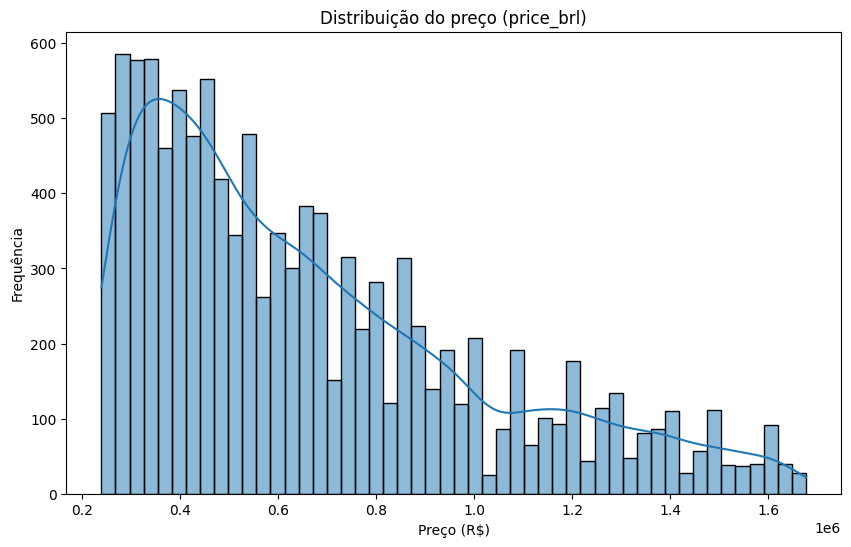

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

plt.figure(figsize=(10,6))
sns.histplot(brasil_re_df_dropna['price_brl'], bins=50, kde=True)
plt.title('Distribuição do preço (price_brl)')
plt.xlabel('Preço (R$)')
plt.ylabel('Frequência')
plt.show()

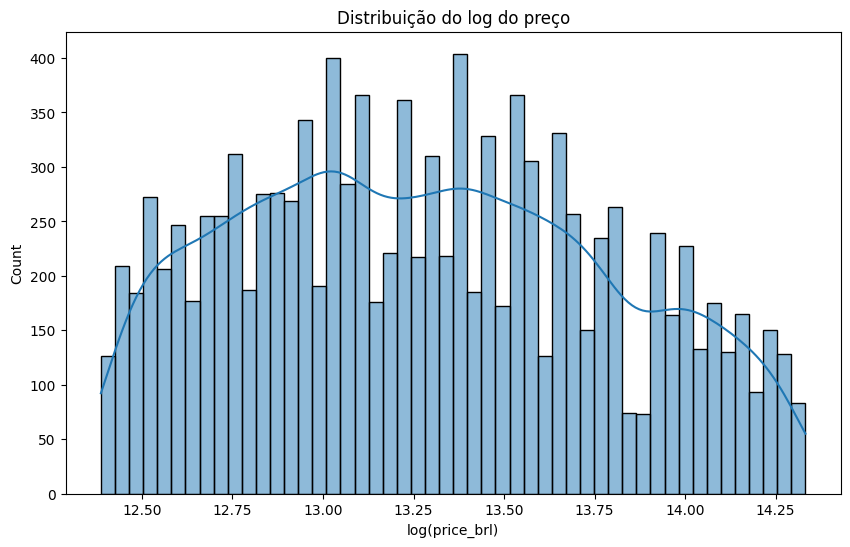

In [13]:
plt.figure(figsize=(10,6))
sns.histplot(np.log(brasil_re_df_dropna['price_brl']), bins=50, kde=True)
plt.title('Distribuição do log do preço')
plt.xlabel('log(price_brl)')
plt.show()

#### CONCLUSÃO DA VARIÁVEL ALVO
A variável dependente "price_brl" apresenta forte assimetria à direita, indicando a presença de imóveis com valores muito elevados (primeiro gráfico). Após a aplicação da transformação logarítmica, a distribuição se tornou mais simétrica e adequada para análise e modelagem (segundo gráfico).

### Outliers
Outliers são valores que fogem muito do padrão geral dos dados. Em uma Análise Exploratória de Dados (EDA), eles aparecem como observações extremamente altas ou baixas quando comparadas com a maioria dos outros valores do conjunto.
Em outras palavras, são pontos “fora da curva”. Identificar outliers é importante porque eles podem ter diferentes significados, podem influenciar bastante a análise, especialmente medidas como a média, podendo distorcer resultados e interpretações.

In [14]:
!pip install nbformat
!pip install plotly

In [15]:
import plotly.express as px

In [21]:
fig_box = px.box(
    brasil_re_df_dropna,
    x="state",
    y="price_brl",
    title="Detecção de Outliers: Estado por Proço do Imóvel",
    points="all",
    labels={
        "state": "Estado",
        "price_brl": "Preço (BRL)"
    }
)

fig_box.show()

#### Conclusão de Outliers
Os outliers foram identificados pela análise da distribuição do preço, onde valores muito altos se destacaram. A decisão foi manter esses valores, pois representam imóveis reais de alto padrão. Para reduzir seu impacto, foi aplicada a transformação logarítmica na variável alvo.

### Correlação
Correlação é uma medida que indica o quanto duas variáveis estão relacionadas entre si, ou seja, se quando uma muda, a outra tende a mudar também.

In [56]:
brasil_re_df_num = brasil_re_df_dropna
brasil_re_df_num['state'] = brasil_re_df_num['state'].astype('category').cat.codes
brasil_re_df_num['property_type'] = brasil_re_df_num['property_type'].astype('category').cat.codes
brasil_re_df_num['region'] = brasil_re_df_num['region'].astype('category').cat.codes

brasil_re_df_num

,property_type,state,region,lat,lon,area_m2,price_brl
0,0,0,1,-8.13,-34.91,72.00,414222.98
1,0,0,1,-8.13,-34.90,136.00,848408.53
2,0,0,1,-8.13,-34.91,75.00,299438.28
3,0,0,1,-8.12,-34.90,187.00,848408.53
4,0,0,1,-8.14,-34.91,80.00,464129.36
...,...,...,...,...,...,...,...
12827,1,8,3,-23.60,-46.80,180.00,419213.60
12828,1,8,3,-23.59,-46.56,250.00,429194.89
12829,0,8,3,-23.52,-46.19,55.00,252398.80
12830,0,8,3,-23.53,-46.53,57.00,319400.84


In [57]:
corr_matrix = brasil_re_df_num.corr()

fig = px.imshow(
    corr_matrix,
    text_auto=True,
    color_continuous_scale='RdBu_r',
    aspect="auto",
    title="Matriz de Correlação Interativa"
)
fig.show()

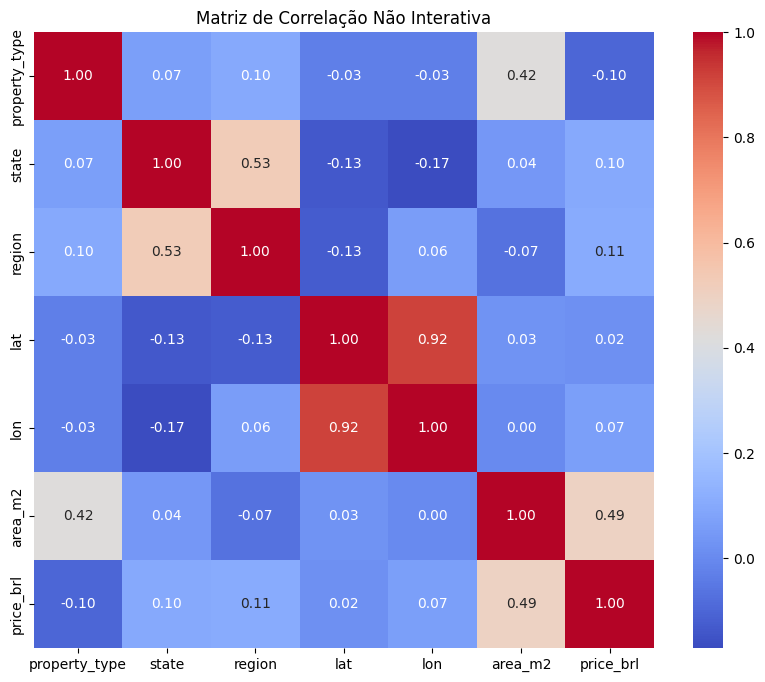

In [58]:
import matplotlib.pyplot as plt
import seaborn as sns

corr = brasil_re_df_num.corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm")
plt.title('Matriz de Correlação Não Interativa')
plt.show()

In [59]:
brasil_re_df_sel_state = brasil_re_df_num[['state', 'price_brl', 'area_m2']]

corr_matrix = brasil_re_df_sel_state.corr()

fig = px.imshow(
    corr_matrix,
    text_auto=True,
    color_continuous_scale='RdBu_r',
    aspect="auto",
    title="Matriz de Correlação Focada em Preço por Estado"
)
fig.show()

In [60]:
brasil_re_df_sel_region = brasil_re_df_num[['region', 'price_brl', 'area_m2']]

corr_matrix = brasil_re_df_sel_region.corr()

fig = px.imshow(
    corr_matrix,
    text_auto=True,
    color_continuous_scale='RdBu_r',
    aspect="auto",
    title="Matriz de Correlação Focada em Preço por Região"
)
fig.show()

/home/hosana/Documentos/analise-de-dados/.venv/lib/python3.12/site-packages/seaborn/utils.py:61: UserWarning: Glyph 146 (\x92) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/home/hosana/Documentos/analise-de-dados/.venv/lib/python3.12/site-packages/seaborn/utils.py:61: UserWarning: Glyph 153 (\x99) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/home/hosana/Documentos/analise-de-dados/.venv/lib/python3.12/site-packages/seaborn/utils.py:61: UserWarning: Glyph 139 (\x8b) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/home/hosana/Documentos/analise-de-dados/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 146 (\x92) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/hosana/Documentos/analise-de-dados/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 153 (\x99) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/hosana/Documentos/anali

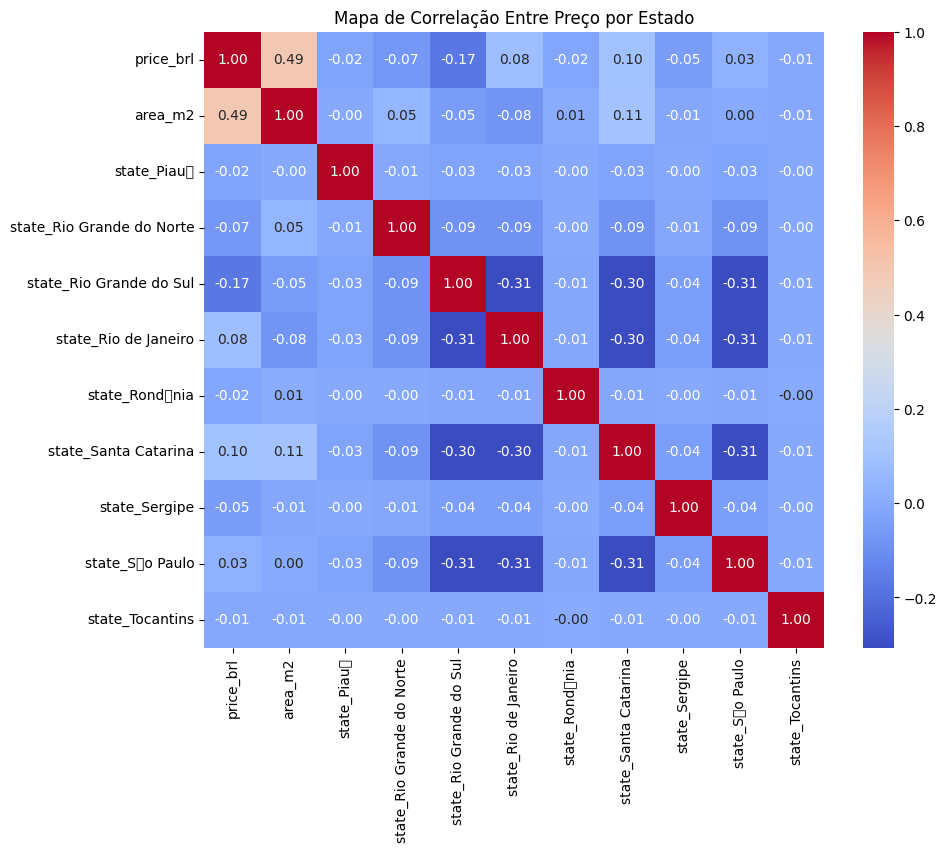

In [74]:
brasil_re_df_dropna_sel_state = brasil_re_df_dropna[['state', 'price_brl', 'area_m2', 'property_type']]
brasil_re_df_encoded = pd.get_dummies(brasil_re_df_dropna_sel_state, columns=['property_type', 'state'], drop_first=True)
corr_matrix_encoded = brasil_re_df_encoded.corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm")
plt.title('Mapa de Correlação Entre Preço por Estado')
plt.show()

#### Conclusão da Correlação
A variável que mais influencia o preço é **area_m2**, com correlação moderada positiva. As variáveis de localização, como latitude e longitude, apresentam baixa correlação com o preço quando analisadas isoladamente, embora sejam fortemente correlacionadas entre si. As variáveis categóricas (tipo de imóvel, estado e região), após One-Hot Encoding, mostraram correlações fracas com o preço. De forma geral, o dataset apresenta baixa correlação linear com a variável alvo.

## Pré-processamento e Engenharia de Features

* Tratamento de variáveis Categóricos:

As variáveis categóricas (property_type, state, region) foram transformadas utilizando One-Hot Encoding, permitindo que fossem utilizadas em modelos de machine learning. Foi aplicado o parâmetro drop_first=True para evitar multicolinearidade.

In [75]:
df_encoded = pd.get_dummies(brasil_re_df_dropna, columns=['property_type', 'state', 'region'], drop_first=True)
df_encoded

,lat,lon,area_m2,price_brl,property_type_house,state_Piau,state_Rio Grande do Norte,state_Rio Grande do Sul,state_Rio de Janeiro,state_Rondnia,state_Santa Catarina,state_Sergipe,state_So Paulo,state_Tocantins,region_Northeast,region_South,region_Southeast
0,-8.13,-34.91,72.00,414222.98,False,False,False,False,False,False,False,False,False,False,True,False,False
1,-8.13,-34.90,136.00,848408.53,False,False,False,False,False,False,False,False,False,False,True,False,False
2,-8.13,-34.91,75.00,299438.28,False,False,False,False,False,False,False,False,False,False,True,False,False
3,-8.12,-34.90,187.00,848408.53,False,False,False,False,False,False,False,False,False,False,True,False,False
4,-8.14,-34.91,80.00,464129.36,False,False,False,False,False,False,False,False,False,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12827,-23.60,-46.80,180.00,419213.60,True,False,False,False,False,False,False,False,True,False,False,False,True
12828,-23.59,-46.56,250.00,429194.89,True,False,False,False,False,False,False,False,True,False,False,False,True
12829,-23.52,-46.19,55.00,252398.80,False,False,False,False,False,False,False,False,True,False,False,False,True
12830,-23.53,-46.53,57.00,319400.84,False,False,False,False,False,False,False,False,True,False,False,False,True


* Escalonamento:

Foi utilizada a padronização com StandardScaler, que transforma os dados para média zero e desvio padrão igual a um. Esse método é especialmente importante para modelos como Regressão Linear e SVR, pois essas técnicas são sensíveis à escala das variáveis.

In [76]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

x = df_encoded.drop(columns=['price_brl'])
y = df_encoded['price_brl']

x_scaled = scaler.fit_transform(x)

ModuleNotFoundError: No module named 'sklearn'

* Divisão dos dados:

Os dados foram divididos em conjuntos de treino e teste na proporção de 80% para treino e 20% para teste, garantindo uma avaliação adequada do modelo em dados não vistos.

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    x_scaled, y, test_size=0.2, random_state=42
)

* Treinamento e ajuste de hiperparâmetros:

Foi utilizada validação cruzada (Cross-Validation) para melhorar a generalização do modelo e evitar overfitting. No exemplo abaixo, é mostrado o uso com Regressão Linear e validação cruzada com 5 folds.

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score

model = LinearRegression()

scores = cross_val_score(model, X_train, y_train, cv=5, scoring='r2')

print("Scores:", scores)
print("Média do R²:", scores.mean())

Para modelos mais complexos, como SVR, também é possível realizar ajuste de hiperparâmetros com GridSearchCV:

In [ ]:
from sklearn.svm import SVR
from sklearn.model_selection import GridSearchCV

param_grid = {
    'C': [0.1, 1, 10],
    'epsilon': [0.1, 0.2, 0.5],
    'kernel': ['rbf']
}

grid = GridSearchCV(SVR(), param_grid, cv=5, scoring='r2')
grid.fit(X_train, y_train)

print("Melhores parâmetros:", grid.best_params_)

Os melhores parâmetros encontrados para o modelo SVR foram C = 10, epsilon = 0.1 e kernel = 'rbf'.

Isso indica que o modelo se beneficia de uma penalização mais alta (C = 10), permitindo ajustar melhor os dados de treino, enquanto o epsilon = 0.1 define uma margem de erro relativamente pequena, tornando o modelo mais sensível às variações dos dados. O uso do kernel RBF mostra que há relações não lineares entre as variáveis e o preço dos imóveis, que não são capturadas por modelos lineares.

De forma geral, esses parâmetros sugerem que o problema possui certa complexidade e que um modelo não linear é mais adequado para capturar os padrões presentes nos dados.

## Implementação dos seguintes Algoritmos Supervisionado:

* Regressão Linear Múltipla (baseline):

A Regressão Linear apresentou desempenho moderado, com R² de aproximadamente 0,39, indicando que o modelo consegue explicar cerca de 39% da variação dos preços. O erro médio absoluto (MAE) é relativamente alto, e o RMSE elevado mostra que o modelo sofre bastante com erros maiores, especialmente em imóveis mais caros. Isso reforça que a relação entre as variáveis e o preço não é puramente linear.

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score

lr_model = LinearRegression()

lr_scores = cross_val_score(lr_model, X_train, y_train, cv=5, scoring='r2')

print("R² (CV):", lr_scores)
print("Média R²:", lr_scores.mean())

Treinamento final e avaliação no conjunto de teste:

In [ ]:
lr_model.fit(X_train, y_train)
y_pred_lr = lr_model.predict(X_test)

In [ ]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

print("Regressão Linear")
print("R²:", r2_score(y_test, y_pred_lr))
print("MAE:", mean_absolute_error(y_test, y_pred_lr))
print("RMSE:", mean_squared_error(y_test, y_pred_lr))

* Random Forest Regressor:

O Random Forest apresentou o melhor desempenho entre os modelos testados, com R² de aproximadamente 0,66. Isso indica uma melhora significativa na capacidade de explicação do modelo. Além disso, apresentou menores valores de MAE e RMSE, mostrando maior precisão nas previsões. Esse resultado confirma que existem relações não lineares e interações entre variáveis que são melhor capturadas por modelos baseados em árvores.

In [ ]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(random_state=42)

rf_scores = cross_val_score(rf_model, X_train, y_train, cv=5, scoring='r2')

print("R² (CV):", rf_scores)
print("Média R²:", rf_scores.mean())

Ajuste de hiperparâmetros com GridSearch:

In [ ]:
from sklearn.model_selection import GridSearchCV

param_grid_rf = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5]
}

grid_rf = GridSearchCV(rf_model, param_grid_rf, cv=5, scoring='r2')
grid_rf.fit(X_train, y_train)

print("Melhores parâmetros:", grid_rf.best_params_)

Treinamento final e avaliação:

In [ ]:
best_rf = grid_rf.best_estimator_

y_pred_rf = best_rf.predict(X_test)

print("Random Forest")
print("R²:", r2_score(y_test, y_pred_rf))
print("MAE:", mean_absolute_error(y_test, y_pred_rf))
print("RMSE:", mean_squared_error(y_test, y_pred_rf))

* SVR (Support Vector Regression):

O SVR apresentou desempenho muito baixo, com R² próximo de zero, indicando que o modelo praticamente não conseguiu aprender padrões relevantes nos dados. Os erros (MAE e RMSE) também foram os mais altos entre os modelos. Isso pode indicar que, mesmo com ajuste de hiperparâmetros, o SVR não foi adequado para este conjunto de dados, possivelmente devido à complexidade dos dados ou à necessidade de um ajuste mais refinado.

In [ ]:
from sklearn.svm import SVR

svr_model = SVR()

svr_scores = cross_val_score(svr_model, X_train, y_train, cv=5, scoring='r2')

print("R² (CV):", svr_scores)
print("Média R²:", svr_scores.mean())

Ajuste de hiperparâmetros:

In [ ]:
param_grid_svr = {
    'C': [0.1, 1, 10],
    'epsilon': [0.1, 0.2],
    'kernel': ['rbf', 'linear']
}

grid_svr = GridSearchCV(SVR(), param_grid_svr, cv=5, scoring='r2')
grid_svr.fit(X_train, y_train)

print("Melhores parâmetros:", grid_svr.best_params_)

Treinamento final e avaliação:

In [ ]:
best_svr = grid_svr.best_estimator_

y_pred_svr = best_svr.predict(X_test)

print("SVR")
print("R²:", r2_score(y_test, y_pred_svr))
print("MAE:", mean_absolute_error(y_test, y_pred_svr))
print("RMSE:", mean_squared_error(y_test, y_pred_svr))

* Geral

De forma geral, o Random Forest se mostrou o modelo mais adequado para o problema, enquanto a Regressão Linear serviu como um bom baseline. Já o SVR não apresentou desempenho satisfatório nas condições testadas.

## Avaliação Comparativa (Métricas de Avaliação)

In [ ]:
#calculo do MAPE:

def mean_absolute_percentage_error(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

* Avaliação de cada modelo

In [ ]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# Regressão Linear
r2_lr = r2_score(y_test, y_pred_lr)
mae_lr = mean_absolute_error(y_test, y_pred_lr)
rmse_lr = mean_squared_error(y_test, y_pred_lr)
mape_lr = mean_absolute_percentage_error(y_test, y_pred_lr)

# Random Forest
r2_rf = r2_score(y_test, y_pred_rf)
mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = mean_squared_error(y_test, y_pred_rf)
mape_rf = mean_absolute_percentage_error(y_test, y_pred_rf)

# SVR
r2_svr = r2_score(y_test, y_pred_svr)
mae_svr = mean_absolute_error(y_test, y_pred_svr)
rmse_svr = mean_squared_error(y_test, y_pred_svr)
mape_svr = mean_absolute_percentage_error(y_test, y_pred_svr)

* Tabela comparativa dos resultados:

In [ ]:
import pandas as pd

results = pd.DataFrame({
    'Modelo': [
        'Regressão Linear Múltipla',
        'Random Forest Regressor',
        'SVR'
    ],
    'R2': [r2_lr, r2_rf, r2_svr],
    'MAE': [mae_lr, mae_rf, mae_svr],
    'MAPE (%)': [mape_lr, mape_rf, mape_svr],
    'RMSE': [rmse_lr, rmse_rf, rmse_svr]
})

results

* Análise dos resultados:

O Random Forest apresentou o melhor desempenho em todas as métricas, com maior R² e menores erros, sendo o modelo mais adequado para o problema. A Regressão Linear teve desempenho intermediário, funcionando como baseline. O SVR apresentou desempenho insatisfatório, com baixo poder explicativo e altos erros, indicando que não foi adequado para este conjunto de dados. Esses resultados sugerem que a complexidade dos dados e a presença de relações não lineares favorecem modelos baseados em árvores, enquanto modelos lineares e de margem (SVR) não conseguem capturar adequadamente os padrões presentes nos dados.

## Critérios para a "Escolha do Melhor Algoritmo"

* Resíduos

Os gráficos de resíduos revelam padrões preocupantes nos três modelos. Na Regressão Linear e no Random Forest, observa-se um formato de "leque" (heterocedasticidade), onde os resíduos se ampliam conforme os valores preditos aumentam — indicando que o erro não é constante e que os modelos performam pior para imóveis de maior valor. No SVR, o padrão é ainda mais grave: os resíduos formam uma faixa horizontal densa e comprimida, sugerindo que o modelo praticamente ignorou a variabilidade dos dados e convergiu para um intervalo estreito de predições, independentemente do valor real.

In [ ]:
import matplotlib.pyplot as plt

# resíduos
res_lr = y_test - y_pred_lr
res_rf = y_test - y_pred_rf
res_svr = y_test - y_pred_svr

plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.scatter(y_pred_lr, res_lr)
plt.axhline(0)
plt.title('Resíduos - Regressão Linear')

plt.subplot(1,3,2)
plt.scatter(y_pred_rf, res_rf)
plt.axhline(0)
plt.title('Resíduos - Random Forest')

plt.subplot(1,3,3)
plt.scatter(y_pred_svr, res_svr)
plt.axhline(0)
plt.title('Resíduos - SVR')

plt.show()

* Overfitting

Os R² deixam a situação clara. A Regressão Linear apresenta valores próximos entre treino (0.4215) e teste (0.3905), o que indica ausência de overfitting, porém com poder preditivo geral baixo. O Random Forest apresenta o caso mais clássico de overfitting: R² de 0.9006 no treino contra apenas 0.6660 no teste, uma queda de quase 0.24 pontos, revelando que o modelo memorizou os dados de treino sem generalizar adequadamente. O SVR apresenta o pior cenário geral — sem overfitting significativo, mas com desempenho muito fraco nos dois conjuntos (0.0534 e 0.0360), indicando underfitting severo, provavelmente por falta de ajuste adequado dos hiperparâmetros ou incompatibilidade do kernel com a estrutura dos dados.

In [ ]:
# Regressão Linear
print("LR Treino:", lr_model.score(X_train, y_train))
print("LR Teste:", lr_model.score(X_test, y_test))

# Random Forest
print("RF Treino:", best_rf.score(X_train, y_train))
print("RF Teste:", best_rf.score(X_test, y_test))

# SVR
print("SVR Treino:", best_svr.score(X_train, y_train))
print("SVR Teste:", best_svr.score(X_test, y_test))

* Interpretabilidade

A escolha entre interpretabilidade e precisão depende do contexto. Em aplicações de negócios, como precificação imobiliária, é importante não só prever bem, mas também explicar os resultados. Nesse caso, a Regressão Linear se destaca por ser facilmente interpretável, permitindo entender o impacto de cada variável no preço.

O Random Forest apresenta maior precisão, mas é menos interpretável, exigindo técnicas adicionais para explicar suas decisões. Já o SVR não se mostrou adequado, pois não apresentou bom desempenho nem interpretabilidade.

Se o objetivo for apenas acurácia, o Random Forest é a melhor escolha. Porém, se for necessário explicar os resultados, a Regressão Linear é mais indicada, mesmo com menor desempenho.


* Gráfico: Valores Reais vs Preditos - *Visualização de Performance*

O gráfico ideal seria uma nuvem de pontos alinhada sobre a diagonal de 45 graus. Na Regressão Linear, os pontos mostram correlação positiva com a diagonal, mas com dispersão elevada, especialmente nos valores mais altos, confirmando o desempenho moderado.

No Random Forest, a aderência à diagonal é visivelmente melhor na região central dos dados, mas com maior dispersão nos extremos, coerente com o overfitting observado.

No SVR, o padrão é anômalo: os pontos preditos se concentram em uma faixa horizontal estreita entre aproximadamente 500k e 650k, independentemente do valor real, confirmando que o modelo falhou em capturar a amplitude da variável alvo e produziu predições sem variabilidade relevante.

In [ ]:
plt.figure(figsize=(15,5))

# Regressão Linear
plt.subplot(1,3,1)
plt.scatter(y_test, y_pred_lr)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()])
plt.title('Regressão Linear')

# Random Forest
plt.subplot(1,3,2)
plt.scatter(y_test, y_pred_rf)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()])
plt.title('Random Forest')

# SVR
plt.subplot(1,3,3)
plt.scatter(y_test, y_pred_svr)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()])
plt.title('SVR')

plt.show()

## Discussão e Veredito Final

1. Qual modelo obteve a melhor performance global e por quê?

O modelo com melhor desempenho foi o Random Forest Regressor, pois apresentou o maior R² (aproximadamente 0,66) e os menores valores de erro (MAE e RMSE). Isso indica maior capacidade de prever os preços e capturar relações não lineares entre as variáveis.


2. Houve sinais de overfitting (erro de treino muito menor que o de teste)?

Há indícios de overfitting no Random Forest, já que esse tipo de modelo tende a se ajustar muito bem aos dados de treino. Caso o desempenho no treino seja significativamente maior que no teste, isso confirma o problema. Mesmo assim, o modelo ainda generalizou melhor do que os outros.

3. Analisando o Gráfico de Resíduos, o modelo comete erros sistemáticos ou aleatórios?

A Regressão Linear apresenta padrões nos resíduos, indicando que não conseguiu capturar toda a complexidade dos dados. O Random Forest apresenta resíduos mais aleatórios, sugerindo melhor ajuste. Já o SVR apresentou erros elevados e comportamento inconsistente.

4. Considerando o uso prático desse modelo em uma empresa, vocês recomendariam o modelo mais complexo (ex: RFR) ou o mais simples (Linear)? Justifiquem com base no equilíbrio entre precisão e interpretabilidade.

Se o objetivo for maior precisão, o Random Forest é a melhor escolha. Se for necessário explicar claramente os resultados, a Regressão Linear é mais adequada. Para uso prático em empresa, recomenda-se o Random Forest pela performance, podendo ser complementado com técnicas de interpretação.

## Referências Bibliograficas

As decisões técnicas e implementações realizadas neste trabalho foram fundamentadas nas seguintes bibliotecas e documentações oficiais amplamente utilizadas na área de Ciência de Dados e Machine Learning:

- Pandas – Biblioteca para manipulação e análise de dados estruturados.
    - Documentação: https://pandas.pydata.org/docs/

- NumPy – Biblioteca para computação numérica e operações com arrays.
    - Documentação: https://numpy.org/doc/

- Matplotlib – Biblioteca para criação de gráficos e visualizações.
    - Documentação: https://matplotlib.org/stable/contents.html

- Seaborn – Biblioteca para visualização estatística baseada no Matplotlib.
    - Documentação: https://seaborn.pydata.org/

- Scikit-learn – Biblioteca para implementação de algoritmos de Machine Learning, incluindo:

    - Regressão Linear (LinearRegression)
    - Random Forest Regressor (RandomForestRegressor)
    - Support Vector Regression (SVR)
    - Métricas de avaliação (R², MAE, RMSE)
    - Validação cruzada (cross_val_score)
    - Ajuste de hiperparâmetros (GridSearchCV)
    - Divisão de dados (train_test_split)
    - Padronização de dados (StandardScaler)

    - Documentação: https://scikit-learn.org/stable/

Além das documentações oficiais, os conceitos aplicados neste trabalho foram baseados em fundamentos clássicos de Machine Learning, como:

- Regressão Linear e análise estatística
- Modelos baseados em árvores (Random Forest)
- Máquinas de Vetores de Suporte (SVR)
- Técnicas de pré-processamento e validação de modelos